# 07 - Inference

Chạy inference trên ảnh mới (đơn lẻ + hàng loạt) bằng checkpoint đã train, và export model sang định
dạng triển khai (ONNX) cho môi trường không có ultralytics/PyTorch (edge device, C++ runtime...).

**Checkpoint hiện tại**: `outputs/checkpoints/best.pt` - vẫn là checkpoint **tạm 2-epoch smoke test**
(xem `reports/training_report.md`). Pipeline dưới đây tự động dùng checkpoint mới sau khi full training
thật ghi đè - không cần sửa code.

## 0. Setup

Load `configs/inference.yaml`, load model qua `src/inference/predictor.py`.

In [1]:
import os
import sys
import random
import shutil

import yaml
import torch
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, os.path.abspath(".."))
from src.inference.predictor import load_predictor, predict_image, save_annotated
from src.inference.batch_predict import batch_predict
from src.inference.export import export_model

with open("../configs/inference.yaml", encoding="utf-8") as f:
    infer_cfg = yaml.safe_load(f)

checkpoint_path = os.path.abspath(os.path.join("..", infer_cfg["checkpoint"]))
sample_dir = os.path.abspath(os.path.join("..", infer_cfg["input_dir"]))
output_dir = os.path.abspath(os.path.join("..", infer_cfg["output_dir"]))
device = 0 if torch.cuda.is_available() else "cpu"

model = load_predictor(checkpoint_path)
print("Checkpoint:", checkpoint_path)
print("Classes:", model.names)
print("Sample dir:", sample_dir)
print("Output dir:", output_dir)
print("conf/iou:", infer_cfg["conf_threshold"], "/", infer_cfg["iou_threshold"], "| imgsz:", infer_cfg["image_size"][0])

Checkpoint: D:\Thermal_project\outputs\checkpoints\best.pt
Classes: {0: 'Human'}
Sample dir: D:\Thermal_project\data\sample
Output dir: D:\Thermal_project\outputs\predictions
conf/iou: 0.15 / 0.45 | imgsz: 640


## 1. Chuẩn bị ảnh mẫu

`data/sample/` (input_dir mặc định trong `configs/inference.yaml`) hiện đang trống. Copy vài ảnh từ tập
**test** (chưa dùng để train) sang đây để minh hoạ inference trên "ảnh mới".

In [2]:
os.makedirs(sample_dir, exist_ok=True)
existing = [f for f in os.listdir(sample_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

if not existing:
    test_dir = os.path.abspath("../data/processed/images/test")
    test_images = os.listdir(test_dir)
    chosen = random.sample(test_images, min(8, len(test_images)))
    for fname in chosen:
        shutil.copy2(os.path.join(test_dir, fname), os.path.join(sample_dir, fname))
    print(f"Da copy {len(chosen)} anh tu test set sang {sample_dir}")
else:
    print(f"data/sample da co san {len(existing)} anh, khong copy them.")

sample_images = sorted(f for f in os.listdir(sample_dir) if f.lower().endswith((".jpg", ".jpeg", ".png")))
print("So anh mau:", len(sample_images))

data/sample da co san 8 anh, khong copy them.
So anh mau: 8


## 2. Inference trên 1 ảnh

Anh: D:\Thermal_project\data\sample\1497.jpg
So nguoi phat hien: 1
Confidence: [0.705]
Da luu anh ket qua: D:\Thermal_project\outputs\predictions\demo_1497.jpg


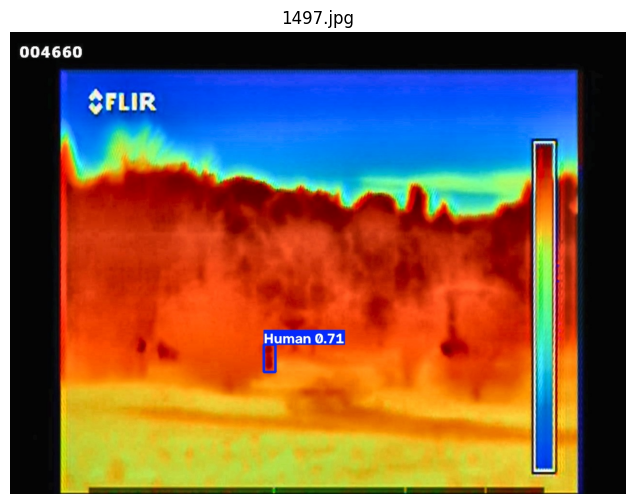

In [3]:
demo_image = os.path.join(sample_dir, sample_images[0])
result = predict_image(
    model, demo_image,
    conf=infer_cfg["conf_threshold"], iou=infer_cfg["iou_threshold"],
    imgsz=infer_cfg["image_size"][0], device=device,
)

print("Anh:", demo_image)
print("So nguoi phat hien:", len(result.boxes))
print("Confidence:", [round(c, 3) for c in result.boxes.conf.tolist()])

annotated_path = os.path.join(output_dir, "demo_" + os.path.basename(demo_image))
os.makedirs(output_dir, exist_ok=True)
save_annotated(result, annotated_path)
print("Da luu anh ket qua:", annotated_path)

os.makedirs("../reports/figures", exist_ok=True)
shutil.copy2(annotated_path, "../reports/figures/07_demo_inference.jpg")

plt.figure(figsize=(8, 6))
plt.imshow(Image.open(annotated_path))
plt.axis("off")
plt.title(os.path.basename(demo_image))
plt.show()

## 3. Inference hàng loạt

Chạy trên toàn bộ `data/sample/`, lưu ảnh đã vẽ box vào `outputs/predictions/` kèm bảng tổng hợp
`summary.csv` (số người phát hiện + confidence mỗi ảnh) - dùng `src/inference/batch_predict.py`.

In [4]:
rows, summary_path = batch_predict(
    model, input_dir=sample_dir, output_dir=output_dir,
    conf=infer_cfg["conf_threshold"], iou=infer_cfg["iou_threshold"],
    imgsz=infer_cfg["image_size"][0], device=device,
)

print(f"Da xu ly {len(rows)} anh, luu tai {output_dir}")
print(f"Summary: {summary_path}\n")
for r in rows:
    print(f"  {r['image']}: {r['num_detections']} nguoi, "
          f"max_conf={r['max_confidence']}, mean_conf={r['mean_confidence']}")

Da xu ly 8 anh, luu tai D:\Thermal_project\outputs\predictions
Summary: D:\Thermal_project\outputs\predictions\summary.csv

  1497.jpg: 1 nguoi, max_conf=0.7051263451576233, mean_conf=0.7051263451576233
  2979.jpg: 1 nguoi, max_conf=0.7386134266853333, mean_conf=0.7386134266853333
  3492.jpg: 4 nguoi, max_conf=0.9012657999992371, mean_conf=0.7249654605984688
  3549.jpg: 2 nguoi, max_conf=0.909369707107544, mean_conf=0.8778705298900604
  4740.jpg: 1 nguoi, max_conf=0.7229909896850586, mean_conf=0.7229909896850586
  4975.jpg: 1 nguoi, max_conf=0.8501843810081482, mean_conf=0.8501843810081482
  5011.jpg: 1 nguoi, max_conf=0.6430613994598389, mean_conf=0.6430613994598389
  6803.jpg: 1 nguoi, max_conf=0.7075953483581543, mean_conf=0.7075953483581543


## 4. Export model sang ONNX

ONNX chạy được bằng ONNX Runtime mà không cần cài PyTorch/ultralytics đầy đủ - phù hợp triển khai trên
edge device hoặc tích hợp vào hệ thống camera an ninh thực tế (không nhất thiết dùng Python).

In [5]:
onnx_path = export_model(model, format="onnx", imgsz=infer_cfg["image_size"][0])
print("Da export ONNX tai:", onnx_path)
print("Kich thuoc file:", f"{os.path.getsize(onnx_path) / 1e6:.1f} MB")

Ultralytics 8.4.98  Python-3.10.20 torch-2.11.0+cu128 CPU (11th Gen Intel Core i7-11800H @ 2.30GHz)



PyTorch: starting from 'D:\Thermal_project\outputs\checkpoints\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)



ONNX: starting export with onnx 1.22.0 opset 20...


ONNX: slimming with onnxslim 0.1.94...


ONNX: export success  2.1s, saved as 'D:\Thermal_project\outputs\checkpoints\best.onnx' (42.7 MB)



Export complete (2.4s)
Results saved to D:\Thermal_project\outputs\checkpoints\best.onnx
Predict:         yolo predict task=detect model=D:\Thermal_project\outputs\checkpoints\best.onnx imgsz=640 
Validate:        yolo val task=detect model=D:\Thermal_project\outputs\checkpoints\best.onnx imgsz=640 data=D:\Thermal_project\data\processed\data.yaml  
Visualize:       https://netron.app


Da export ONNX tai: D:\Thermal_project\outputs\checkpoints\best.onnx
Kich thuoc file: 44.7 MB


## 5. Tóm tắt

In [6]:
print("=" * 60)
print("TÓM TẮT INFERENCE")
print("=" * 60)
print(f"Checkpoint: {checkpoint_path} (TẠM - 2 epoch smoke test, chưa phải full training)")
print(f"Đã inference {len(rows)} ảnh mẫu, kết quả tại {output_dir}")
print(f"Đã export ONNX: {onnx_path}")
print()
print("=> Sau khi full training thật xong (05_training.ipynb, RUN_FULL_TRAINING=True),")
print("   chạy lại notebook này để inference/export bằng model thật.")

TÓM TẮT INFERENCE
Checkpoint: D:\Thermal_project\outputs\checkpoints\best.pt (TẠM - 2 epoch smoke test, chưa phải full training)
Đã inference 8 ảnh mẫu, kết quả tại D:\Thermal_project\outputs\predictions
Đã export ONNX: D:\Thermal_project\outputs\checkpoints\best.onnx

=> Sau khi full training thật xong (05_training.ipynb, RUN_FULL_TRAINING=True),
   chạy lại notebook này để inference/export bằng model thật.
